<a href="https://colab.research.google.com/github/Akshatupadhaya/APS-LAB/blob/main/Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Greedy Knapsack Problem (Fractional)
In this lab, we explore the Fractional Knapsack Problem, a fundamental optimization problem that demonstrates the Greedy Algorithmic Paradigm.
We will implement it using greedy selection (based on value-to-weight ratio) and analyze its time and space complexity.

- Created by Dr. Ajay

# Problem Definition
Given a set of
n
n items, each with:
Value vi
Weight wi
A knapsack with maximum capacity **W**

Goal: maximize total value that can be put in the knapsack.
Constraint: You may take fractions of items.

Greedy Strategy:

*  Sort items by decreasing ratio vi/wi
*  Select items fully until knapsack is full.
*  Take fraction of the next item if capacity remains.

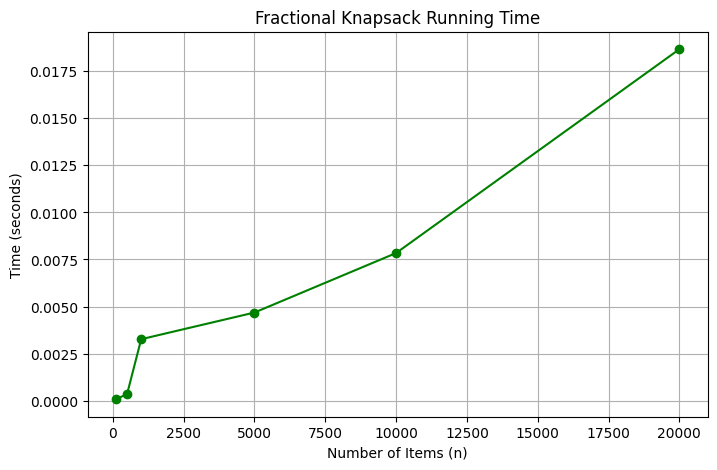

In [1]:
#write code for the above problem
import time
import random
import matplotlib.pyplot as plt

def fractional_knapsack(values, weights, capacity):
    n = len(values)

    ratio = [(values[i] / weights[i], values[i], weights[i]) for i in range(n)]

    ratio.sort(key=lambda x: x[0], reverse=True)

    total_value = 0.0
    remaining_capacity = capacity

    for r, v, w in ratio:
        if remaining_capacity >= w:

            total_value += v
            remaining_capacity -= w
        else:

            total_value += r * remaining_capacity
            break

    return total_value


sizes = [100, 500, 1000, 5000, 10000, 20000]
times = []

for n in sizes:
    values = [random.randint(1, 1000) for _ in range(n)]
    weights = [random.randint(1, 100) for _ in range(n)]
    capacity = sum(weights) // 2

    start = time.time()
    fractional_knapsack(values, weights, capacity)
    end = time.time()
    times.append(end - start)


plt.figure(figsize=(8,5))
plt.plot(sizes, times, marker='o', linestyle='-', color='g')
plt.title("Fractional Knapsack Running Time")
plt.xlabel("Number of Items (n)")
plt.ylabel("Time (seconds)")
plt.grid(True)
plt.show()


In this lab, we implement Huffman Coding, a greedy algorithm used for lossless data compression.
It assigns variable-length binary codes to input symbols based on their frequencies, ensuring that more frequent symbols receive shorter codes and less frequent symbols receive longer codes.

This algorithm constructs a binary tree (Huffman Tree) where each leaf node represents a character, and the path from the root to a leaf gives the character’s binary code.

Use:
Huffman Tree Construction using a Min-Priority Queue (Min-Heap).
Code generation for each character.
Encoding and decoding using the generated Huffman codes.
Complexity analysis and comparison with fixed-length encoding.

# Pseudocode:
1. Create a leaf node for each character and insert all nodes into a
2. min-heap by frequency.
   *  While the heap has more than one node:
   * Extract two nodes with the lowest frequencies.
   * Create a new internal node with frequency = sum of the two.
   *  Set the two extracted nodes as left and right children.
   *  Insert the new node back into the min-heap.
3. The remaining node is the root of the Huffman Tree.

4. Traverse the tree:
   * Assign 0 for left edge and 1 for right edge.
   * The resulting paths from root to leaves give Huffman codes.

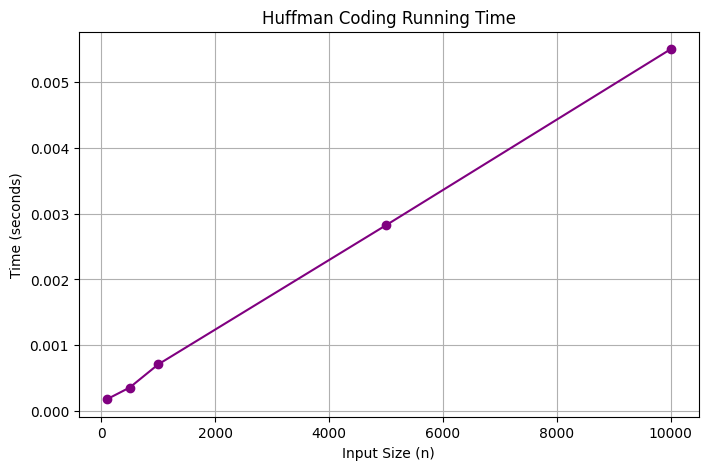

In [2]:
# write code for above
import heapq
import time
import random
import matplotlib.pyplot as plt


class Node:
    def __init__(self, char, freq):
        self.char = char
        self.freq = freq
        self.left = None
        self.right = None


    def __lt__(self, other):
        return self.freq < other.freq


def build_huffman_tree(freq_map):
    heap = [Node(char, freq) for char, freq in freq_map.items()]
    heapq.heapify(heap)

    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)
        merged = Node(None, left.freq + right.freq)
        merged.left = left
        merged.right = right
        heapq.heappush(heap, merged)

    return heap[0]


def generate_codes(root, current_code="", codes={}):
    if root is None:
        return
    if root.char is not None:
        codes[root.char] = current_code
        return
    generate_codes(root.left, current_code + "0", codes)
    generate_codes(root.right, current_code + "1", codes)
    return codes


def huffman_encode(text, codes):
    return "".join(codes[ch] for ch in text)


def huffman_decode(encoded_text, root):
    decoded = []
    node = root
    for bit in encoded_text:
        node = node.left if bit == "0" else node.right
        if node.char is not None:
            decoded.append(node.char)
            node = root
    return "".join(decoded)


sizes = [100, 500, 1000, 5000, 10000]
times = []

for n in sizes:

    text = "".join(random.choice("abcdefghijklmnopqrstuvwxyz") for _ in range(n))
    freq_map = {}
    for ch in text:
        freq_map[ch] = freq_map.get(ch, 0) + 1

    start = time.time()
    root = build_huffman_tree(freq_map)
    codes = generate_codes(root)
    encoded = huffman_encode(text, codes)
    decoded = huffman_decode(encoded, root)
    end = time.time()

    times.append(end - start)


plt.figure(figsize=(8,5))
plt.plot(sizes, times, marker='o', linestyle='-', color='purple')
plt.title("Huffman Coding Running Time")
plt.xlabel("Input Size (n)")
plt.ylabel("Time (seconds)")
plt.grid(True)
plt.show()
